# Objectives

- Main goal: If a person eats 100g of each seaweed, what percentage of his/her daily AS or LSS does he/she get?
- Show ANSES nutritional reference values for specific nutrients
- These reference values determine the quantity (in grams, milligrams or micgrograms) of each nutrient it is recommended to consume daily
- The charts show what percentage of reference value, for each nutrient, 100g of each seaweed corresponds to
- This way we can see that 100g of Wakamé atlantique provides 44,1% of daily recommended iron intake

# imports

In [107]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


from lxml import etree # for importing other datRNPet that hRNP 'alim_nom_fr' + 'ALIM_INDEX_FR' columns

import unicodedata # for cleaning CEVA df before merging

In [108]:
pd.set_option('display.max_rows', None)

### cleaned combined (CEVA + ciqual bRNPe) df 

In [109]:
df_combined_cleaned = pd.read_csv('data/processed/df_ciqual_ceva_seaweeds_cleaned')

df_combined_cleaned.head()

,alim_code,alim_grp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_nom_eng,alim_nom_fr,"Energy, Regulation EU No 1169/2011 (kJ/100g)","Energy, Regulation EU No 1169/2011 (kcal/100g)",Water (g/100g),Fibres (g/100g),...,Vitamin C (mg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Vitamin K1 (µg/100g),Zinc (mg/100g),Iodine (µg/100g),approx_count,seaweed_type,seaweed_name_Eng,seaweed_name_French
0,10041.0,4.0,"meat, egg and fish","seafood, raw","Abalone or ormer or sea ear, raw","Ormeau, cru",422.0,99.6,74.6,0.0000,...,2.000000,0.0000,4.00,NaN,0.82,NaN,0,unknown,"Abalone or ormer or sea ear, raw","Ormeau, cru"
1,12112.0,5.0,milk and milk products,cheese and similar,"Abondance cheese, from cow's milk",Abondance,1630.0,393.0,37.2,0.0000,...,0.375000,0.1875,0.75,2.25,3.50,15.0,6,unknown,"Abondance cheese, from cow's milk",Abondance
2,13404.0,2.0,"fruits, vegetables, legumes and nuts",fruits,"Acerola, pulp, raw, sampled in the island of L...","Cerise acérola, pulpe, crue, prélevée à la Ma...",NaN,NaN,93.1,NaN,...,2850.000000,NaN,NaN,NaN,NaN,NaN,0,unknown,"Acerola, pulp, raw, sampled in the island of L...","Cerise acérola, pulpe, crue, prélevée à la Ma..."
3,11168.0,10.0,miscellaneous,sauces,"Aioli sauce (garlic and olive oil mayonnaise),...","Sauce aïoli, préemballée",NaN,NaN,NaN,0.4200,...,NaN,NaN,NaN,NaN,NaN,NaN,0,unknown,"Aioli sauce (garlic and olive oil mayonnaise),...","Sauce aïoli, préemballée"
4,26006.0,4.0,"meat, egg and fish","fish, raw","Alaska pollock, raw","Lieu ou colin d'Alaska, cru",300.0,70.8,81.2,0.1275,...,0.000001,1.1000,0.36,0.10,0.41,78.2,1,unknown,"Alaska pollock, raw","Lieu ou colin d'Alaska, cru"


## filter dataset to only contain reduced nutrients list

In [110]:
df_combined_clean = df_combined_cleaned.rename(columns={
    'Protein, crude, N x 6.25 (g/100g)': 'Protein (g/100g)'
})

In [111]:
# Trimmed down nutrients for public-friendly comparison
nutrients_list_step1 = [
    "Fibres (g/100g)",
    "Protein (g/100g)",
    "Calcium (mg/100g)",
    "Iodine (µg/100g)",
    "Fat (g/100g)",
    "FA saturated (g/100g)",
    "Iron (mg/100g)"
]

In [112]:
df = df_combined_clean[
    ['alim_code', 'alim_nom_eng', 'alim_nom_fr', 'alim_ssgrp_nom_eng', 'seaweed_type'] + nutrients_list_step1
]

df.head()

,alim_code,alim_nom_eng,alim_nom_fr,alim_ssgrp_nom_eng,seaweed_type,Fibres (g/100g),Protein (g/100g),Calcium (mg/100g),Iodine (µg/100g),Fat (g/100g),FA saturated (g/100g),Iron (mg/100g)
0,10041.0,"Abalone or ormer or sea ear, raw","Ormeau, cru","seafood, raw",unknown,0.0000,14.40,31.0,NaN,0.830,0.150,5.90
1,12112.0,"Abondance cheese, from cow's milk",Abondance,cheese and similar,unknown,0.0000,26.60,760.0,15.0,31.600,20.100,0.09
2,13404.0,"Acerola, pulp, raw, sampled in the island of L...","Cerise acérola, pulpe, crue, prélevée à la Ma...",fruits,unknown,NaN,0.56,NaN,NaN,0.097,NaN,NaN
3,11168.0,"Aioli sauce (garlic and olive oil mayonnaise),...","Sauce aïoli, préemballée",sauces,unknown,0.4200,1.13,NaN,NaN,41.000,NaN,NaN
4,26006.0,"Alaska pollock, raw","Lieu ou colin d'Alaska, cru","fish, raw",unknown,0.1275,16.30,12.8,78.2,0.610,0.015,0.40


## ANSES nutritional reference values - AS & LSS for adult women

In [113]:
from numpy import nan


df_RI_women = pd.DataFrame({
    "Nutrient": ["Fibres_g", "Protein_g", "Calcium_mg", "Iron_mg", "Iodine_µg"],
    "AS / RNP": [25, 49.8, 950, 16, 150],  # Apports satisfaisants
    "LSS": [nan, nan, 2500, 40, 600 ]  # Limite supérieure de sécurité
})


df_RI_men = pd.DataFrame({
    "Nutrient": ["Fibres_g", "Protein_g", "Calcium_mg", "Iron_mg", "Iodine_µg"],
    "AS / RNP": [25, 58.1, 950, 11, 150],   # Apports satisfaisants
    "LSS": [nan, nan, 2500, 40, 600 ]  # Limite supérieure de sécurité
})



In [114]:
print(df_RI_women)

print()

df_RI_men

     Nutrient  AS / RNP     LSS
0    Fibres_g      25.0     NaN
1   Protein_g      49.8     NaN
2  Calcium_mg     950.0  2500.0
3     Iron_mg      16.0    40.0
4   Iodine_µg     150.0   600.0



,Nutrient,AS / RNP,LSS
0,Fibres_g,25.0,NaN
1,Protein_g,58.1,NaN
2,Calcium_mg,950.0,2500.0
3,Iron_mg,11.0,40.0
4,Iodine_µg,150.0,600.0


## Extract essential data for RI percentage chart

In [115]:
df_RI_perc = df[['seaweed_type', 'alim_nom_fr', 'alim_ssgrp_nom_eng', 'Fibres (g/100g)', 'Protein (g/100g)', 'Calcium (mg/100g)', 'Iron (mg/100g)', 'Iodine (µg/100g)']]

df_RI_perc_filtered = df_RI_perc[df_RI_perc['alim_ssgrp_nom_eng'] == 'seaweed']

df_RI_perc_filtered = df_RI_perc_filtered.drop(columns='alim_ssgrp_nom_eng')

df_RI_perc_filtered.head()


,seaweed_type,alim_nom_fr,Fibres (g/100g),Protein (g/100g),Calcium (mg/100g),Iron (mg/100g),Iodine (µg/100g)
101,algue brune,"Wakamé atlantique (Alaria esculenta), séchée ...",42.9,12.2,771.0,44.6,362000.0
268,algue brune,"Fucus vésiculeux (Fucus vesiculosus), séché ou...",46.7,6.4,1256.0,13.1,40500.0
479,algue rouge,Lichen de mer ou pioca ou goémon rouge (Chond...,35.5,16.7,911.0,18.1,31300.0
943,algue rouge,"Dulse (Palmaria palmata), séchée ou déshydratée",29.2,16.9,577.0,29.3,229000.0
1258,algue rouge,"Gracilaire ou ogonori (Gracilaria verrucosa),...",25.4,17.8,770.0,36.0,355800.0


# Remove info about dried or dehydrated & remove "algue" from seaweed_type column

In [116]:
# Rename multiple columns
# df_RI_perc_filtered = df_RI_perc_filtered.rename(columns={
#     'Fibres (g/100g)': 'Fibres_g',
#     'Protein (g/100g)': 'Protein_g',
#     'Calcium (mg/100g)': 'Iron_mg',
#     'Iodine (µg/100g)': 'Iodine_µg'
# })

# remove info 'séchée' ou 'déshydraté' du nom de l'algue
df_RI_perc_filtered["alim_nom_fr"] = (df_RI_perc_filtered["alim_nom_fr"].str.split(",", n=1)).str[0]

df_RI_perc_filtered["seaweed_type"] = df_RI_perc_filtered["seaweed_type"].str.replace("algue ", "")

df_RI_perc_filtered.head()

,seaweed_type,alim_nom_fr,Fibres (g/100g),Protein (g/100g),Calcium (mg/100g),Iron (mg/100g),Iodine (µg/100g)
101,brune,Wakamé atlantique (Alaria esculenta),42.9,12.2,771.0,44.6,362000.0
268,brune,Fucus vésiculeux (Fucus vesiculosus),46.7,6.4,1256.0,13.1,40500.0
479,rouge,Lichen de mer ou pioca ou goémon rouge (Chond...,35.5,16.7,911.0,18.1,31300.0
943,rouge,Dulse (Palmaria palmata),29.2,16.9,577.0,29.3,229000.0
1258,rouge,Gracilaire ou ogonori (Gracilaria verrucosa),25.4,17.8,770.0,36.0,355800.0


## Rename columns for clarity

In [117]:
#Rename multiple columns
df_RI_perc_filtered = df_RI_perc_filtered.rename(columns={
    "seaweed_type": "Type d'algue",
    "alim_nom_fr": "Algue",
})



## Dictionaries for AS - RNP for women

In [118]:
from numpy import nan


df_RI_women = pd.DataFrame({
    "Nutrient": ["Fibres_g", "Protein_g", "Calcium_mg", "Iron_mg", "Iodine_µg"],
    "AS / RNP": [25, 49.8, 950, 16, 150],  # Apports satisfaisants
    "LSS": [None, None, 2500, 40, 600 ]  # Limite supérieure de sécurité
})


df_RI_men = pd.DataFrame({
    "Nutrient": ["Fibres_g", "Protein_g", "Calcium_mg", "Iron_mg", "Iodine_µg"],
    "AS / RNP": [25, 58.1, 950, 11, 150],   # Apports satisfaisants
    "LSS": [None, None, 2500, 40, 600 ]  # Limite supérieure de sécurité
})


In [119]:
df_RI_women

,Nutrient,AS / RNP,LSS
0,Fibres_g,25.0,NaN
1,Protein_g,49.8,NaN
2,Calcium_mg,950.0,2500.0
3,Iron_mg,16.0,40.0
4,Iodine_µg,150.0,600.0


## pivot from long to wide

In [120]:
df_RI_perc_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 101 to 3042
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Type d'algue       19 non-null     object 
 1   Algue              19 non-null     object 
 2   Fibres (g/100g)    18 non-null     float64
 3   Protein (g/100g)   19 non-null     float64
 4   Calcium (mg/100g)  19 non-null     float64
 5   Iron (mg/100g)     19 non-null     float64
 6   Iodine (µg/100g)   17 non-null     float64
dtypes: float64(5), object(2)
memory usage: 1.2+ KB


# Option 2: using AS_dict (and not df)

In [121]:
from numpy import nan

AS_dict_women = {
    "Fibres (g/100g)": 25,      # g/day,  Sources: https://www.anses.fr/system/files/NUT2012SA0103Ra-2.pdf, https://www.anses.fr/system/files/NUT-Ra-Fibres.pdf
    "Protein (g/100g)": 49.8,     # g/day pour une femme de 60 kg -->. ANC protein = 0.83 g/kg poids corporel, Source:
    "Calcium (mg/100g)": 950,   # mg/day, Source: https://www.anses.fr/fr/content/les-references-nutritionnelles-en-vitamines-et-mineraux
    "Iron (mg/100g)": 16,       # mg/day (women, varies by population), Source: https://www.anses.fr/fr/content/les-references-nutritionnelles-en-vitamines-et-mineraux
    "Iodine (µg/100g)": 150     # µg/day, Source: https://www.anses.fr/fr/content/les-references-nutritionnelles-en-vitamines-et-mineraux
}

LSS_dict_women = {
    "Fibres (g/100g)": nan,      # g/day (tolerable upper level, if available)
    "Protein (g/100g)": nan,    # g/day
    "Calcium (mg/100g)": 2500,  # mg/day
    "Iron (mg/100g)": 40,       # mg/day, Source: l'avis de l'Efsa de 2024
    "Iodine (µg/100g)": 600     # µg/day
}


AS_dict_men = {
    "Fibres (g/100g)": 25,      # g/day, Source: https://www.anses.fr/system/files/NUT2012SA0103Ra-2.pdf, https://www.anses.fr/system/files/NUT-Ra-Fibres.pdf
    "Protein (g/100g)": 58.1,     # g/day pour un homme de 70 kg -->. ANC protein = 0.83 g/kg poids corporel, Source:https://www.anses.fr/fr/content/les-references-nutritionnelles-en-vitamines-et-mineraux
    "Calcium (mg/100g)": 950,   # mg/day, Source: https://www.anses.fr/fr/content/les-references-nutritionnelles-en-vitamines-et-mineraux
    "Iron (mg/100g)": 11,       # mg/day (women, varies by population), Source: 
    "Iodine (µg/100g)": 150     # µg/day, Source: https://www.anses.fr/fr/content/les-references-nutritionnelles-en-vitamines-et-mineraux
}

LSS_dict_men = {
    "Fibres (g/100g)": nan,      # g/day (tolerable upper level, if available)
    "Protein (g/100g)": nan,    # g/day
    "Calcium (mg/100g)": 2500,  # mg/day
    "Iron (mg/100g)": 40,       # mg/day, Source: l'avis de l'Efsa de 2024, https://www.anses.fr/fr/content/les-references-nutritionnelles-en-vitamines-et-mineraux
    "Iodine (µg/100g)": 600     # µg/day, Source: https://www.anses.fr/fr/content/les-references-nutritionnelles-en-vitamines-et-mineraux
}



# AS = for Iodine, 
# RNP = for Calcium
# ANC protein = 58g is for a person weighing 70kg
# ANC protein: 0.83 g/kg poids corporel, according to: NUT-Ra-Proteines.pdf
# LSS protein = une limite à 20 % de l’AET, according to https://www.anses.fr/fr/system/files/NUT2012SA0103Ra-1.pdf, p. 16
# LSS protein = not official, but AFSSA was leading to wards making it 3.5 g / kg / day, so 245g for a 70 kg person
# protein numbers = AFSSA 2007, according to this article: https://efsa.onlinelibrary.wiley.com/doi/epdf/10.2903/j.efsa.2012.2557

# source pour les minéraux : https://www.anses.fr/fr/content/les-references-nutritionnelles-en-vitamines-et-mineraux, https://anses.hal.science/anses-03431491v1/document
# sources pour les protéines : https://www.anses.fr/system/files/NUT-Ra-Proteines.pdf, https://www.anses.fr/en/system/files/NUT2012SA0103Ra-1EN.pdf
# source for weight references for calculating RNP for protein : https://www.anses.fr/fr/system/files/NUT2012SA0103Ra-2.pdf --> Annexe2, https://efsa.onlinelibrary.wiley.com/doi/pdf/10.2903/j.efsa.2013.3005



## Step 1 - Calculate %AS/RNP and %LSS

In [122]:
df_women = df_RI_perc_filtered.copy()

for nutrient in AS_dict_women.keys():
    as_val_women = AS_dict_women[nutrient]
    lss_val_women = LSS_dict_women[nutrient]

    # Compute %AS and %LSS
    df_women[f"%AS/RNP_{nutrient}"] = df_women[nutrient] / as_val_women * 100
    df_women[f"%LSS_{nutrient}"] = df_women[nutrient] / lss_val_women * 100

# Round for readability
df_women = df_women.round(1)

df_women.head()


,Type d'algue,Algue,Fibres (g/100g),Protein (g/100g),Calcium (mg/100g),Iron (mg/100g),Iodine (µg/100g),%AS/RNP_Fibres (g/100g),%LSS_Fibres (g/100g),%AS/RNP_Protein (g/100g),%LSS_Protein (g/100g),%AS/RNP_Calcium (mg/100g),%LSS_Calcium (mg/100g),%AS/RNP_Iron (mg/100g),%LSS_Iron (mg/100g),%AS/RNP_Iodine (µg/100g),%LSS_Iodine (µg/100g)
101,brune,Wakamé atlantique (Alaria esculenta),42.9,12.2,771.0,44.6,362000.0,171.6,NaN,24.5,NaN,81.2,30.8,278.8,111.5,241333.3,60333.3
268,brune,Fucus vésiculeux (Fucus vesiculosus),46.7,6.4,1256.0,13.1,40500.0,186.8,NaN,12.9,NaN,132.2,50.2,81.9,32.8,27000.0,6750.0
479,rouge,Lichen de mer ou pioca ou goémon rouge (Chond...,35.5,16.7,911.0,18.1,31300.0,142.0,NaN,33.5,NaN,95.9,36.4,113.1,45.2,20866.7,5216.7
943,rouge,Dulse (Palmaria palmata),29.2,16.9,577.0,29.3,229000.0,116.8,NaN,33.9,NaN,60.7,23.1,183.1,73.2,152666.7,38166.7
1258,rouge,Gracilaire ou ogonori (Gracilaria verrucosa),25.4,17.8,770.0,36.0,355800.0,101.6,NaN,35.7,NaN,81.1,30.8,225.0,90.0,237200.0,59300.0


In [123]:
df_men = df_RI_perc_filtered.copy()

for nutrient in AS_dict_men.keys():
    as_val_men = AS_dict_men[nutrient]
    lss_val_men = LSS_dict_men[nutrient]

    # Compute %AS and %LSS
    df_men[f"%AS/RNP_{nutrient}"] = df_men[nutrient] / as_val_men * 100
    df_men[f"%LSS_{nutrient}"] = df_men[nutrient] / lss_val_men * 100

# Round for readability
df_men = df_men.round(1)

df_men.head()


,Type d'algue,Algue,Fibres (g/100g),Protein (g/100g),Calcium (mg/100g),Iron (mg/100g),Iodine (µg/100g),%AS/RNP_Fibres (g/100g),%LSS_Fibres (g/100g),%AS/RNP_Protein (g/100g),%LSS_Protein (g/100g),%AS/RNP_Calcium (mg/100g),%LSS_Calcium (mg/100g),%AS/RNP_Iron (mg/100g),%LSS_Iron (mg/100g),%AS/RNP_Iodine (µg/100g),%LSS_Iodine (µg/100g)
101,brune,Wakamé atlantique (Alaria esculenta),42.9,12.2,771.0,44.6,362000.0,171.6,NaN,21.0,NaN,81.2,30.8,405.5,111.5,241333.3,60333.3
268,brune,Fucus vésiculeux (Fucus vesiculosus),46.7,6.4,1256.0,13.1,40500.0,186.8,NaN,11.0,NaN,132.2,50.2,119.1,32.8,27000.0,6750.0
479,rouge,Lichen de mer ou pioca ou goémon rouge (Chond...,35.5,16.7,911.0,18.1,31300.0,142.0,NaN,28.7,NaN,95.9,36.4,164.5,45.2,20866.7,5216.7
943,rouge,Dulse (Palmaria palmata),29.2,16.9,577.0,29.3,229000.0,116.8,NaN,29.1,NaN,60.7,23.1,266.4,73.2,152666.7,38166.7
1258,rouge,Gracilaire ou ogonori (Gracilaria verrucosa),25.4,17.8,770.0,36.0,355800.0,101.6,NaN,30.6,NaN,81.1,30.8,327.3,90.0,237200.0,59300.0


## Reorder columns

In [124]:
# Nutrients of interest
nutrients = ["Fibres (g/100g)", "Protein (g/100g)", "Calcium (mg/100g)", "Iron (mg/100g)", "Iodine (µg/100g)"]

# Build desired column order
new_order = ["Type d'algue", "Algue"]  # keep identifiers first
for n in nutrients:
    new_order += [n, f"%AS/RNP_{n}", f"%LSS_{n}"]

# Reorder columns in dataframe
df_women = df_women[new_order]


# Remove Agar & Spiruline from list bc they are not part of approved edible seaweeds
df_women_15 = df_women[
    ~(
        df_women['Algue'].str.contains('Spir') | df_women['Algue'].str.contains('Agar')
        )
        ]


print(df_women.shape)
print(df_women_15.shape)

(19, 17)
(16, 17)


In [125]:
# Reorder columns in dataframe 
df_men = df_men[new_order]

# Remove Agar & Spiruline from list bc they are not part of approved edible seaweeds
df_men_15 = df_men[
    ~(
        df_men['Algue'].str.contains('Spir') | df_men['Algue'].str.contains('Agar')
        )
        ]


print(df_men.shape)
print(df_men_15.shape)

(19, 17)
(16, 17)


In [126]:
df_women_15.sort_values("Type d'algue").to_excel("charts_references_nutritionnels/seaweed_nutrients_RV_women_unformatted.xlsx", engine="openpyxl", index=False)
df_men_15.sort_values("Type d'algue").to_excel("charts_references_nutritionnels/seaweed_nutrients_RV_men_unformatted.xlsx", engine="openpyxl", index=False)


# Then below the table:
# * Values are the nutrient amounts found in 100 g of seaweed.
# %RNP = % of the daily recommended intake.
# %LSS = % of the tolerable upper safety limit.

## Convert % columns from float to integer + add '%' symbol

In [127]:
df_women_15.columns

Index(['Type d'algue', 'Algue', 'Fibres (g/100g)', '%AS/RNP_Fibres (g/100g)',
       '%LSS_Fibres (g/100g)', 'Protein (g/100g)', '%AS/RNP_Protein (g/100g)',
       '%LSS_Protein (g/100g)', 'Calcium (mg/100g)',
       '%AS/RNP_Calcium (mg/100g)', '%LSS_Calcium (mg/100g)', 'Iron (mg/100g)',
       '%AS/RNP_Iron (mg/100g)', '%LSS_Iron (mg/100g)', 'Iodine (µg/100g)',
       '%AS/RNP_Iodine (µg/100g)', '%LSS_Iodine (µg/100g)'],
      dtype='object')

## Women

Prepare women’s nutrient dataset: Rename Columns, Format %, and Build MultiIndex Structure”

In [128]:
# FINAL PROPER WORKING CODE

###### KEEP THIS VERSION

df_display_women = df_women_15.sort_values("Type d'algue")  # sort alphabetically


# Start with renamed df
df_display_women = df_women_15.rename(columns={
    "Algue": "Macroalgue",
    "Fibres (g/100g)": "Fibres (g/100 g)*",
    "%AS/RNP_Fibres (g/100g)": "%AS/RNP Fibres",
    "%LSS_Fibres (g/100g)": "%LSS Fibres",
    "Protein (g/100g)": "Protéines (g/100 g)*",
    "%AS/RNP_Protein (g/100g)": "%AS/RNP Protéines",
    "%LSS_Protein (g/100g)": "%LSS Protéines",
    "Calcium (mg/100g)": "Calcium (mg/100 g)*",
    "%AS/RNP_Calcium (mg/100g)": "%AS/RNP Calcium",
    "%LSS_Calcium (mg/100g)": "%LSS Calcium",
    "Iron (mg/100g)": "Fer (mg/100 g)*",
    "%AS/RNP_Iron (mg/100g)": "%AS/RNP Fer",
    "%LSS_Iron (mg/100g)": "%LSS Fer",
    "Iodine (µg/100g)": "Iode (µg/100 g)*",
    "%AS/RNP_Iodine (µg/100g)": "%AS/RNP Iode",
    "%LSS_Iodine (µg/100g)": "%LSS Iode"
})

# Convert floats to percentages as strings with "%"
for col in df_display_women.columns:
    if "%AS/RNP" in col or "%LSS" in col:
        df_display_women[col] = df_display_women[col].apply(
            lambda x: f"{round(x,1)}%" if pd.notna(x) else ""
        )

# Create MultiIndex for columns
# Map current column names to (top-level, sub-level)
col_mapping = {
    "Fibres (g/100 g)*": ("Fibres", "g"),
    "%AS/RNP Fibres": ("Fibres", "%RNP"),
    "%LSS Fibres": ("Fibres", "%LSS"),
    
    "Protéines (g/100 g)*": ("Protéines", "g"),
    "%AS/RNP Protéines": ("Protéines", "%RNP"),
    "%LSS Protéines": ("Protéines", "%LSS"),
    
    "Calcium (mg/100 g)*": ("Calcium", "mg"),
    "%AS/RNP Calcium": ("Calcium", "%RNP"),
    "%LSS Calcium": ("Calcium", "%LSS"),
    
    "Fer (mg/100 g)*": ("Fer", "mg"),
    "%AS/RNP Fer": ("Fer", "%RNP"),
    "%LSS Fer": ("Fer", "%LSS"),
    
    "Iode (µg/100 g)*": ("Iode", "µg"),
    "%AS/RNP Iode": ("Iode", "%RNP"),
    "%LSS Iode": ("Iode", "%LSS"),

    "Type d'algue": ("", "Type"),
    "Macroalgue": ("", "Macroalgue")
}

df_display_women.columns = pd.MultiIndex.from_tuples([col_mapping[c] for c in df_display_women.columns])

# Set Macroalgue as index
df_display_women = df_display_women.set_index(("", "Macroalgue"))

# Display
df_display_women.head()


Fibres               \
                                                     Type      g    %RNP %LSS   
(, Macroalgue)                                                                  
 Wakamé atlantique (Alaria esculenta)               brune   42.9  171.6%        
Fucus vésiculeux (Fucus vesiculosus)                brune   46.7  186.8%        
 Lichen de mer ou pioca ou goémon rouge (Chondr...  rouge   35.5  142.0%        
 Dulse (Palmaria palmata)                           rouge   29.2  116.8%        
 Gracilaire ou ogonori (Gracilaria verrucosa)       rouge   25.4  101.6%        

                                                   Protéines              \
                                                           g   %RNP %LSS   
(, Macroalgue)                                                             
 Wakamé atlantique (Alaria esculenta)                   12.2  24.5%        
Fucus vésiculeux (Fucus vesiculosus)                     6.4  12.9%        
 Lichen de mer ou pioca ou goémon rouge (Chondr...      16.7  33.5%        
 Dulse (Palmaria palmata)                               16.9  33.9%        
 Gracilaire ou ogonori (Gracilaria verrucosa)           17.8  35.7%        

                                                   Calcium                 \
                                                        mg    %RNP   %LSS   
(, Macroalgue)                                                              
 Wakamé atlantique (Alaria esculenta)                771.0   81.2%  30.8%   
Fucus vésiculeux (Fucus vesiculosus)                1256.0  132.2%  50.2%   
 Lichen de mer ou pioca ou goémon rouge (Chondr...   911.0   95.9%  36.4%   
 Dulse (Palmaria palmata)                            577.0   60.7%  23.1%   
 Gracilaire ou ogonori (Gracilaria verrucosa)        770.0   81.1%  30.8%   

                                                     Fer                  \
                                                      mg    %RNP    %LSS   
(, Macroalgue)                                                             
 Wakamé atlantique (Alaria esculenta)               44.6  278.8%  111.5%   
Fucus vésiculeux (Fucus vesiculosus)                13.1   81.9%   32.8%   
 Lichen de mer ou pioca ou goémon rouge (Chondr...  18.1  113.1%   45.2%   
 Dulse (Palmaria palmata)                           29.3  183.1%   73.2%   
 Gracilaire ou ogonori (Gracilaria verrucosa)       36.0  225.0%   90.0%   

                                                        Iode             \
                                                          µg       %RNP   
(, Macroalgue)                                                            
 Wakamé atlantique (Alaria esculenta)               362000.0  241333.3%   
Fucus vésiculeux (Fucus vesiculosus)                 40500.0   27000.0%   
 Lichen de mer ou pioca ou goémon rouge (Chondr...   31300.0   20866.7%   
 Dulse (Palmaria palmata)                           229000.0  152666.7%   
 Gracilaire ou ogonori (Gracilaria verrucosa)       355800.0  237200.0%   

                                                              
                                                        %LSS  
(, Macroalgue)                                                
 Wakamé atlantique (Alaria esculenta)               60333.3%  
Fucus vésiculeux (Fucus vesiculosus)                 6750.0%  
 Lichen de mer ou pioca ou goémon rouge (Chondr...   5216.7%  
 Dulse (Palmaria palmata)                           38166.7%  
 Gracilaire ou ogonori (Gracilaria verrucosa)       59300.0%

#### Format % Columns and Highlight RNP & LSS Values in df_display_women = MULTIINDEX

In [129]:
# Sort first
df_display_women = df_women_15.sort_values("Type d'algue").rename(columns={
    "Algue": "Algue",
    "Fibres (g/100g)": "Fibres (g/100 g)*",
    "%AS/RNP_Fibres (g/100g)": "%AS/RNP Fibres",
    "%LSS_Fibres (g/100g)": "%LSS Fibres",
    "Protein (g/100g)": "Protéines (g/100 g)*",
    "%AS/RNP_Protein (g/100g)": "%AS/RNP Protéines",
    "%LSS_Protein (g/100g)": "%LSS Protéines",
    "Calcium (mg/100g)": "Calcium (mg/100 g)*",
    "%AS/RNP_Calcium (mg/100g)": "%AS/RNP Calcium",
    "%LSS_Calcium (mg/100g)": "%LSS Calcium",
    "Iron (mg/100g)": "Fer (mg/100 g)*",
    "%AS/RNP_Iron (mg/100g)": "%AS/RNP Fer",
    "%LSS_Iron (mg/100g)": "%LSS Fer",
    "Iodine (µg/100g)": "Iode (µg/100 g)*",
    "%AS/RNP_Iodine (µg/100g)": "%AS/RNP Iode",
    "%LSS_Iodine (µg/100g)": "%LSS Iode"
})

# Round once
df_display_women = df_display_women.round(1)

# MultiIndex mapping
col_mapping = {
    "Fibres (g/100 g)*": ("Fibres", "g"),
    "%AS/RNP Fibres": ("Fibres", "%RNP"),
    "%LSS Fibres": ("Fibres", "%LSS"),
    "Protéines (g/100 g)*": ("Protéines", "g"),
    "%AS/RNP Protéines": ("Protéines", "%RNP"),
    "%LSS Protéines": ("Protéines", "%LSS"),
    "Calcium (mg/100 g)*": ("Calcium", "mg"),
    "%AS/RNP Calcium": ("Calcium", "%RNP"),
    "%LSS Calcium": ("Calcium", "%LSS"),
    "Fer (mg/100 g)*": ("Fer", "mg"),
    "%AS/RNP Fer": ("Fer", "%RNP"),
    "%LSS Fer": ("Fer", "%LSS"),
    "Iode (µg/100 g)*": ("Iode", "µg"),
    "%AS/RNP Iode": ("Iode", "%RNP"),
    "%LSS Iode": ("Iode", "%LSS"),
    "Type d'algue": ("", "Type"),
    "Algue": ("", "Algue")
}

df_display_women.columns = pd.MultiIndex.from_tuples([col_mapping[c] for c in df_display_women.columns])

# Reorder columns
cols = df_display_women.columns.tolist()
type_col = ("", "Type")
algue_col = ("", "Algue")
new_order = [type_col, algue_col] + [c for c in cols if c not in [type_col, algue_col]]
df_display_women = df_display_women[new_order]

# Coloring
def color_rnp(val):
    if isinstance(val, (int, float)):
        return "background-color: #dff0d8" if val < 100 else "background-color: #ffe5b4"
    return None

def color_lss(val):
    if isinstance(val, (int, float)):
        return "background-color: #fde2e2" if val > 100 else "background-color: #dff0d8"
    return None

rnp_cols = [col for col in df_display_women.columns if col[1] == "%RNP"]
lss_cols = [col for col in df_display_women.columns if col[1] == "%LSS"]

styled_women = (
    df_display_women
    .style
    .map(color_rnp, subset=rnp_cols)
    .map(color_lss, subset=lss_cols)
    .format(precision=1)
)

styled_women


## Men

Prepare women’s nutrient dataset: Rename Columns, Format %, and Build MultiIndex Structure”


In [130]:
df_display_men = df_men_15.sort_values("Type d'algue")  # sort alphabetically


# Start with renamed df
df_display_men = df_men_15.rename(columns={
    "Algue": "Macroalgue",
    "Fibres (g/100g)": "Fibres (g/100 g)*",
    "%AS/RNP_Fibres (g/100g)": "%AS/RNP Fibres",
    "%LSS_Fibres (g/100g)": "%LSS Fibres",
    "Protein (g/100g)": "Protéines (g/100 g)*",
    "%AS/RNP_Protein (g/100g)": "%AS/RNP Protéines",
    "%LSS_Protein (g/100g)": "%LSS Protéines",
    "Calcium (mg/100g)": "Calcium (mg/100 g)*",
    "%AS/RNP_Calcium (mg/100g)": "%AS/RNP Calcium",
    "%LSS_Calcium (mg/100g)": "%LSS Calcium",
    "Iron (mg/100g)": "Fer (mg/100 g)*",
    "%AS/RNP_Iron (mg/100g)": "%AS/RNP Fer",
    "%LSS_Iron (mg/100g)": "%LSS Fer",
    "Iodine (µg/100g)": "Iode (µg/100 g)*",
    "%AS/RNP_Iodine (µg/100g)": "%AS/RNP Iode",
    "%LSS_Iodine (µg/100g)": "%LSS Iode"
})

# Convert floats to percentages as strings with "%"
for col in df_display_men.columns:
    if "%AS/RNP" in col or "%LSS" in col:
        df_display_men[col] = df_display_men[col].apply(
            lambda x: f"{round(x,1)}%" if pd.notna(x) else ""
        )

# Create MultiIndex for columns
# Map current column names to (top-level, sub-level)
col_mapping = {
    "Fibres (g/100 g)*": ("Fibres", "g"),
    "%AS/RNP Fibres": ("Fibres", "%RNP"),
    "%LSS Fibres": ("Fibres", "%LSS"),
    
    "Protéines (g/100 g)*": ("Protéines", "g"),
    "%AS/RNP Protéines": ("Protéines", "%RNP"),
    "%LSS Protéines": ("Protéines", "%LSS"),
    
    "Calcium (mg/100 g)*": ("Calcium", "mg"),
    "%AS/RNP Calcium": ("Calcium", "%RNP"),
    "%LSS Calcium": ("Calcium", "%LSS"),
    
    "Fer (mg/100 g)*": ("Fer", "mg"),
    "%AS/RNP Fer": ("Fer", "%RNP"),
    "%LSS Fer": ("Fer", "%LSS"),
    
    "Iode (µg/100 g)*": ("Iode", "µg"),
    "%AS/RNP Iode": ("Iode", "%RNP"),
    "%LSS Iode": ("Iode", "%LSS"),

    "Type d'algue": ("", "Type"),
    "Macroalgue": ("", "Macroalgue")
}

df_display_men.columns = pd.MultiIndex.from_tuples([col_mapping[c] for c in df_display_men.columns])

# Set Macroalgue as index
df_display_men = df_display_men.set_index(("", "Macroalgue"))

# Display
df_display_men.head()


Fibres               \
                                                     Type      g    %RNP %LSS   
(, Macroalgue)                                                                  
 Wakamé atlantique (Alaria esculenta)               brune   42.9  171.6%        
Fucus vésiculeux (Fucus vesiculosus)                brune   46.7  186.8%        
 Lichen de mer ou pioca ou goémon rouge (Chondr...  rouge   35.5  142.0%        
 Dulse (Palmaria palmata)                           rouge   29.2  116.8%        
 Gracilaire ou ogonori (Gracilaria verrucosa)       rouge   25.4  101.6%        

                                                   Protéines              \
                                                           g   %RNP %LSS   
(, Macroalgue)                                                             
 Wakamé atlantique (Alaria esculenta)                   12.2  21.0%        
Fucus vésiculeux (Fucus vesiculosus)                     6.4  11.0%        
 Lichen de mer ou pioca ou goémon rouge (Chondr...      16.7  28.7%        
 Dulse (Palmaria palmata)                               16.9  29.1%        
 Gracilaire ou ogonori (Gracilaria verrucosa)           17.8  30.6%        

                                                   Calcium                 \
                                                        mg    %RNP   %LSS   
(, Macroalgue)                                                              
 Wakamé atlantique (Alaria esculenta)                771.0   81.2%  30.8%   
Fucus vésiculeux (Fucus vesiculosus)                1256.0  132.2%  50.2%   
 Lichen de mer ou pioca ou goémon rouge (Chondr...   911.0   95.9%  36.4%   
 Dulse (Palmaria palmata)                            577.0   60.7%  23.1%   
 Gracilaire ou ogonori (Gracilaria verrucosa)        770.0   81.1%  30.8%   

                                                     Fer                  \
                                                      mg    %RNP    %LSS   
(, Macroalgue)                                                             
 Wakamé atlantique (Alaria esculenta)               44.6  405.5%  111.5%   
Fucus vésiculeux (Fucus vesiculosus)                13.1  119.1%   32.8%   
 Lichen de mer ou pioca ou goémon rouge (Chondr...  18.1  164.5%   45.2%   
 Dulse (Palmaria palmata)                           29.3  266.4%   73.2%   
 Gracilaire ou ogonori (Gracilaria verrucosa)       36.0  327.3%   90.0%   

                                                        Iode             \
                                                          µg       %RNP   
(, Macroalgue)                                                            
 Wakamé atlantique (Alaria esculenta)               362000.0  241333.3%   
Fucus vésiculeux (Fucus vesiculosus)                 40500.0   27000.0%   
 Lichen de mer ou pioca ou goémon rouge (Chondr...   31300.0   20866.7%   
 Dulse (Palmaria palmata)                           229000.0  152666.7%   
 Gracilaire ou ogonori (Gracilaria verrucosa)       355800.0  237200.0%   

                                                              
                                                        %LSS  
(, Macroalgue)                                                
 Wakamé atlantique (Alaria esculenta)               60333.3%  
Fucus vésiculeux (Fucus vesiculosus)                 6750.0%  
 Lichen de mer ou pioca ou goémon rouge (Chondr...   5216.7%  
 Dulse (Palmaria palmata)                           38166.7%  
 Gracilaire ou ogonori (Gracilaria verrucosa)       59300.0%

#### Format % Columns and Highlight RNP & LSS Values in df_display_men = MULTIINDEX

In [131]:
# Sort first
df_display_men = df_men_15.sort_values("Type d'algue").rename(columns={
    "Algue": "Algue",
    "Fibres (g/100g)": "Fibres (g/100 g)*",
    "%AS/RNP_Fibres (g/100g)": "%AS/RNP Fibres",
    "%LSS_Fibres (g/100g)": "%LSS Fibres",
    "Protein (g/100g)": "Protéines (g/100 g)*",
    "%AS/RNP_Protein (g/100g)": "%AS/RNP Protéines",
    "%LSS_Protein (g/100g)": "%LSS Protéines",
    "Calcium (mg/100g)": "Calcium (mg/100 g)*",
    "%AS/RNP_Calcium (mg/100g)": "%AS/RNP Calcium",
    "%LSS_Calcium (mg/100g)": "%LSS Calcium",
    "Iron (mg/100g)": "Fer (mg/100 g)*",
    "%AS/RNP_Iron (mg/100g)": "%AS/RNP Fer",
    "%LSS_Iron (mg/100g)": "%LSS Fer",
    "Iodine (µg/100g)": "Iode (µg/100 g)*",
    "%AS/RNP_Iodine (µg/100g)": "%AS/RNP Iode",
    "%LSS_Iodine (µg/100g)": "%LSS Iode"
})

# Round once
df_display_men = df_display_men.round(1)

# MultiIndex mapping
col_mapping = {
    "Fibres (g/100 g)*": ("Fibres", "g"),
    "%AS/RNP Fibres": ("Fibres", "%RNP"),
    "%LSS Fibres": ("Fibres", "%LSS"),
    "Protéines (g/100 g)*": ("Protéines", "g"),
    "%AS/RNP Protéines": ("Protéines", "%RNP"),
    "%LSS Protéines": ("Protéines", "%LSS"),
    "Calcium (mg/100 g)*": ("Calcium", "mg"),
    "%AS/RNP Calcium": ("Calcium", "%RNP"),
    "%LSS Calcium": ("Calcium", "%LSS"),
    "Fer (mg/100 g)*": ("Fer", "mg"),
    "%AS/RNP Fer": ("Fer", "%RNP"),
    "%LSS Fer": ("Fer", "%LSS"),
    "Iode (µg/100 g)*": ("Iode", "µg"),
    "%AS/RNP Iode": ("Iode", "%RNP"),
    "%LSS Iode": ("Iode", "%LSS"),
    "Type d'algue": ("", "Type"),
    "Algue": ("", "Algue")
}

df_display_men.columns = pd.MultiIndex.from_tuples([col_mapping[c] for c in df_display_men.columns])

# Reorder columns
cols = df_display_men.columns.tolist()
type_col = ("", "Type")
algue_col = ("", "Algue")
new_order = [type_col, algue_col] + [c for c in cols if c not in [type_col, algue_col]]
df_display_men = df_display_men[new_order]

# Coloring
def color_rnp(val):
    if isinstance(val, (int, float)):
        return "background-color: #dff0d8" if val < 100 else "background-color: #ffe5b4"
    return None

def color_lss(val):
    if isinstance(val, (int, float)):
        return "background-color: #fde2e2" if val > 100 else "background-color: #dff0d8"
    return None

rnp_cols = [col for col in df_display_men.columns if col[1] == "%RNP"]
lss_cols = [col for col in df_display_men.columns if col[1] == "%LSS"]

styled_men = (
    df_display_men
    .style
    .map(color_rnp, subset=rnp_cols)
    .map(color_lss, subset=lss_cols)
    .format(precision=1)
)

styled_men


### Save formatted data to excel files

In [132]:
title_women = "Apports nutritionnels de 100 g d’algues par rapport aux valeurs de référence pour les femmes"
title_men = "Apports nutritionnels de 100 g d’algues par rapport aux valeurs de référence pour les femmes"


# WOMEN
with pd.ExcelWriter(
    "charts_references_nutritionnels/seaweed_nutrients_RV_women_formatted.xlsx",
    engine="openpyxl"
) as writer:
    pd.DataFrame([[title_women]]).to_excel(
        writer, sheet_name="Feuil1", index=False, header=False, startrow=0
    )
    df_display_women.to_excel(
        writer, sheet_name="Feuil1", startrow=2
    )


# MEN
with pd.ExcelWriter(
    "charts_references_nutritionnels/seaweed_nutrients_RV_men_formatted.xlsx",
    engine="openpyxl"
) as writer:
    # Row 1: title (no header)
    pd.DataFrame([[title_men]]).to_excel(
        writer, sheet_name="Feuil1", index=False, header=False, startrow=0
    )
    # Row 3+: MultiIndex header + data
    df_display_men.to_excel(
        writer, sheet_name="Feuil1", startrow=2
    )





In [133]:
def color_as_rnp(val):
    """Green if below 100%, red if 100% or more"""
    try:
        return "background-color: #dff0d8" if float(val) < 100 else "background-color: #f5b7b1"
    except:
        return ""

def color_lss(val):
    """Orange if above 80%, red if 100% or more"""
    try:
        if float(val) >= 100:
            return "background-color: #f1948a"
        elif float(val) >= 80:
            return "background-color: #f9e79f"
        else:
            return "background-color: #dff0d8"
    except:
        return ""

# Build list of % columns
as_cols = [c for c in df_women.columns if "%AS/RNP" in c]
lss_cols = [c for c in df_women.columns if "%LSS" in c]

# Apply styles and formatting
styled = (
    df_women.style
    .map(color_as_rnp, subset=as_cols)
    .map(color_lss, subset=lss_cols)
    .format(
        {col: "{:.0f}%" for col in as_cols + lss_cols}  # display as integers with "%"
    )
)

styled


,Type d'algue,Algue,Fibres (g/100g),%AS/RNP_Fibres (g/100g),%LSS_Fibres (g/100g),Protein (g/100g),%AS/RNP_Protein (g/100g),%LSS_Protein (g/100g),Calcium (mg/100g),%AS/RNP_Calcium (mg/100g),%LSS_Calcium (mg/100g),Iron (mg/100g),%AS/RNP_Iron (mg/100g),%LSS_Iron (mg/100g),Iodine (µg/100g),%AS/RNP_Iodine (µg/100g),%LSS_Iodine (µg/100g)
101,brune,Wakamé atlantique (Alaria esculenta),42.900000,172%,nan%,12.200000,24%,nan%,771.000000,81%,31%,44.600000,279%,112%,362000.000000,241333%,60333%
268,brune,Fucus vésiculeux (Fucus vesiculosus),46.700000,187%,nan%,6.400000,13%,nan%,1256.000000,132%,50%,13.100000,82%,33%,40500.000000,27000%,6750%
479,rouge,Lichen de mer ou pioca ou goémon rouge (Chondrus crispus),35.500000,142%,nan%,16.700000,34%,nan%,911.000000,96%,36%,18.100000,113%,45%,31300.000000,20867%,5217%
943,rouge,Dulse (Palmaria palmata),29.200000,117%,nan%,16.900000,34%,nan%,577.000000,61%,23%,29.300000,183%,73%,229000.000000,152667%,38167%
1258,rouge,Gracilaire ou ogonori (Gracilaria verrucosa),25.400000,102%,nan%,17.800000,36%,nan%,770.000000,81%,31%,36.000000,225%,90%,355800.000000,237200%,59300%
1431,brune,Kombu ou kombu japonais (Laminaria japonica),34.100000,136%,nan%,7.900000,16%,nan%,811.000000,85%,32%,13.000000,81%,32%,232800.000000,155200%,38800%
1472,rouge,Nori (Porphyra sp.),36.800000,147%,nan%,30.200000,61%,nan%,440.000000,46%,18%,36.400000,228%,91%,5600.000000,3733%,933%
1849,brune,Ascophylle noueux ou goémon noir (Ascophyllum nodosum),43.600000,174%,nan%,7.400000,15%,nan%,1601.000000,168%,64%,19.300000,121%,48%,68600.000000,45733%,11433%
2516,brune,Kombu royal (Saccharina latissima),30.200000,121%,nan%,9.900000,20%,nan%,838.000000,88%,34%,24.100000,151%,60%,410000.000000,273333%,68333%
2517,verte,Ao-nori (Enteromorpha sp.),35.100000,140%,nan%,13.600000,27%,nan%,1554.000000,164%,62%,205.000000,1281%,512%,9900.000000,6600%,1650%


In [134]:
import pandas as pd

def prepare_long_format(df, id_cols):
    """
    Convert wide nutrient table into long format for plotting.
    Works for both women and men datasets.
    """

    # Melt into long format
    df_long = pd.melt(
        df,
        id_vars=id_cols,
        var_name="Metric",
        value_name="Value"
    )

    # Extract nutrient name
    df_long["Nutrient"] = df_long["Metric"].str.extract(
        r"(Fibres|Protein|Calcium|Iron|Iodine)"
    )

    # Classify metric type (order matters!)
    df_long["MetricType"] = df_long["Metric"].apply(
        lambda x: "%AS/RNP" if "AS/RNP" in x
        else ("%LSS" if "LSS" in x
        else "Raw (per 100g)")
    )

    # Convert values to numeric (remove % if present)
    df_long["Value"] = (
        df_long["Value"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .replace("", pd.NA)
        .astype(float)
    )

    return df_long


### Women

In [135]:
pd.reset_option("display.max_rows")

df_long_women = prepare_long_format(
    df_women,
    id_cols=["Type d'algue", "Algue"]
)

df_long_women

,Type d'algue,Algue,Metric,Value,Nutrient,MetricType
0,brune,Wakamé atlantique (Alaria esculenta),Fibres (g/100g),42.9,Fibres,Raw (per 100g)
1,brune,Fucus vésiculeux (Fucus vesiculosus),Fibres (g/100g),46.7,Fibres,Raw (per 100g)
2,rouge,Lichen de mer ou pioca ou goémon rouge (Chond...,Fibres (g/100g),35.5,Fibres,Raw (per 100g)
3,rouge,Dulse (Palmaria palmata),Fibres (g/100g),29.2,Fibres,Raw (per 100g)
4,rouge,Gracilaire ou ogonori (Gracilaria verrucosa),Fibres (g/100g),25.4,Fibres,Raw (per 100g)
...,...,...,...,...,...,...
280,microalgae,Spiruline (Spirulina sp.),%LSS_Iodine (µg/100g),NaN,Iodine,%LSS
281,brune,Kombu breton (Laminaria digitata),%LSS_Iodine (µg/100g),76466.7,Iodine,%LSS
282,brune,Fucus vésiculeux (Fucus serratus),%LSS_Iodine (µg/100g),6750.0,Iodine,%LSS
283,brune,Fucus vésiculeux (Fucus serratus ou Fucus ves...,%LSS_Iodine (µg/100g),6666.7,Iodine,%LSS


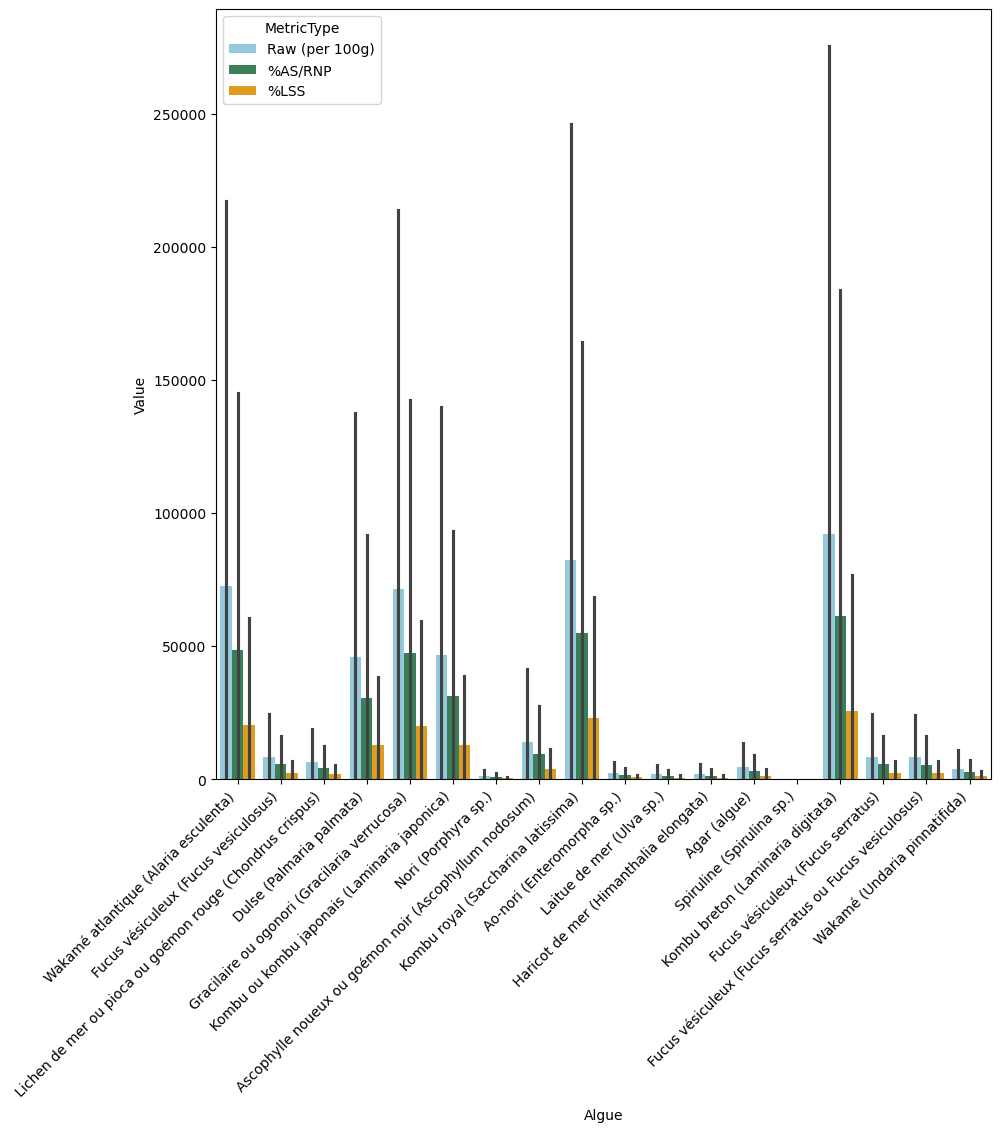

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
sns.barplot(
    data=df_long_women,
    x="Algue",
    y="Value",
    hue="MetricType",
    palette={"Raw (per 100g)": "skyblue",
             "%AS/RNP": "seagreen",
             "%LSS": "orange"}
)
plt.xticks(rotation=45, ha="right")
#plt.tight_layout()
plt.show()


### Men

In [137]:
df_long_men = prepare_long_format(
    df_men,
    id_cols=["Type d'algue", "Algue"]
)


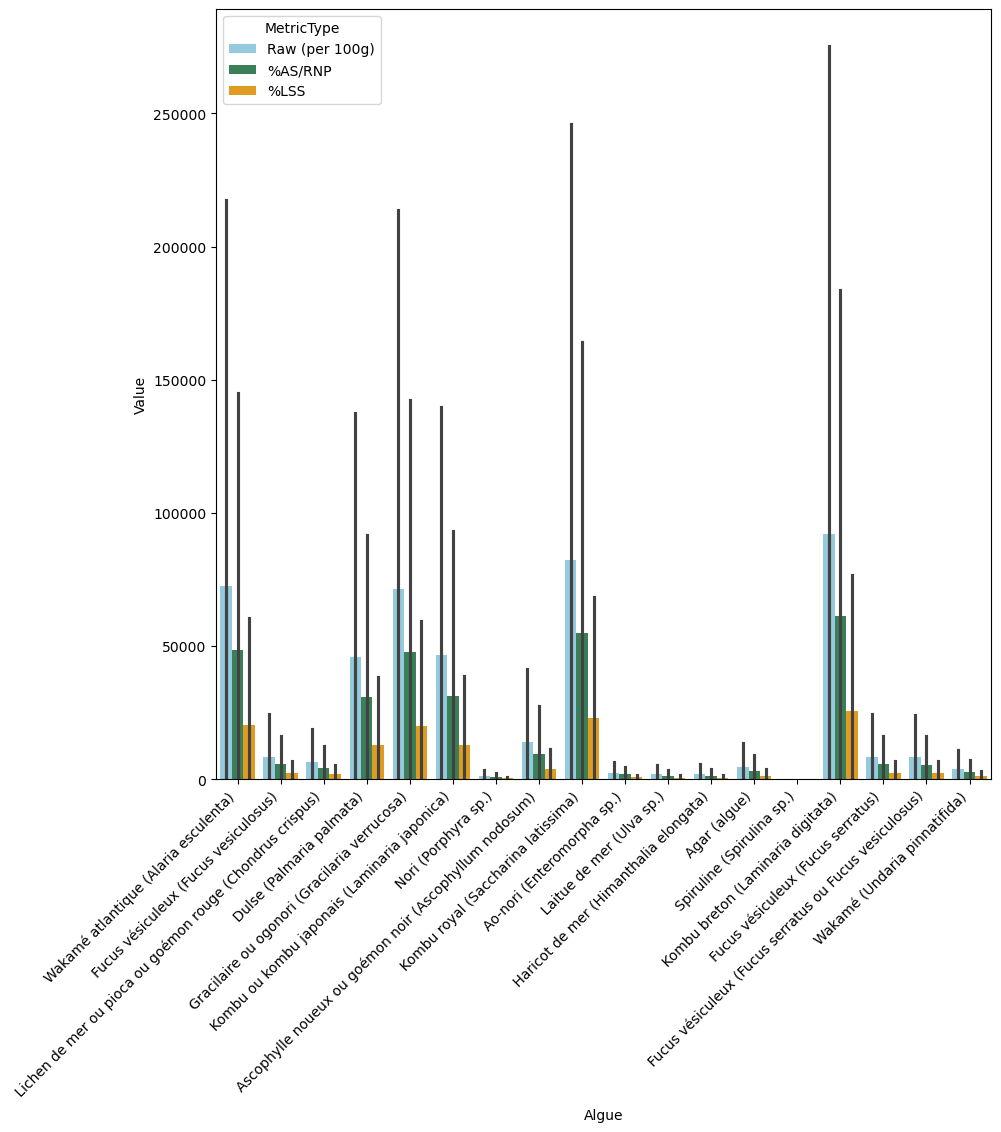

In [138]:
plt.figure(figsize=(10,10))
sns.barplot(
    data=df_long_men,
    x="Algue",
    y="Value",
    hue="MetricType",
    palette={"Raw (per 100g)": "skyblue",
             "%AS/RNP": "seagreen",
             "%LSS": "orange"}
)
plt.xticks(rotation=45, ha="right")
#plt.tight_layout()
plt.show()





In [139]:
# ---- STEP 1: Prepare ----
id_cols = ["Algue", "Type d'algue"]

# ---- STEP 2: Melt wide → long ----
df_long = df_RI_perc_filtered.melt(
    id_vars=id_cols,
    var_name="Nutrient",
    value_name="Amount"
)

# ---- STEP 3: Compute %AS and %LSS ----
df_long["AS/RNP%"] = df_long.apply(
    lambda row: row["Amount"] / AS_dict_women.get(row["Nutrient"], float("nan")) * 100,
    axis=1
)
df_long["LSS%"] = df_long.apply(
    lambda row: row["Amount"] / AS_dict_women.get(row["Nutrient"], float("nan")) * 100,
    axis=1
)

# ---- STEP 4: Pivot back to wide (per seaweed) ----
df_wide = df_long.pivot_table(
    index=id_cols,
    columns="Nutrient",
    values=["Amount", "AS/RNP%", "LSS%"]
)
# Flatten MultiIndex columns
df_wide.columns = [f"{metric}_{nutrient}" for metric, nutrient in df_wide.columns]
df_wide = df_wide.reset_index()



# ---- STEP 5: Display ----
df_wide["Type d'algue"] = df_wide["Type d'algue"].str.split(",", n=1).str[0].str.strip()

df_wide.round(2).head(10)  # show first 10 rows

,Algue,Type d'algue,AS/RNP%_Calcium (mg/100g),AS/RNP%_Fibres (g/100g),AS/RNP%_Iodine (µg/100g),AS/RNP%_Iron (mg/100g),AS/RNP%_Protein (g/100g),Amount_Calcium (mg/100g),Amount_Fibres (g/100g),Amount_Iodine (µg/100g),Amount_Iron (mg/100g),Amount_Protein (g/100g),LSS%_Calcium (mg/100g),LSS%_Fibres (g/100g),LSS%_Iodine (µg/100g),LSS%_Iron (mg/100g),LSS%_Protein (g/100g)
0,Agar (algue),rouge,37.47,2.0,24000.00,53.31,4.92,356.0,0.5,36000.0,8.53,2.45,37.47,2.0,24000.00,53.31,4.92
1,Ao-nori (Enteromorpha sp.),verte,163.58,140.4,6600.00,1281.25,27.31,1554.0,35.1,9900.0,205.00,13.60,163.58,140.4,6600.00,1281.25,27.31
2,Ascophylle noueux ou goémon noir (Ascophyllum...,brune,168.53,174.4,45733.33,120.62,14.86,1601.0,43.6,68600.0,19.30,7.40,168.53,174.4,45733.33,120.62,14.86
3,Dulse (Palmaria palmata),rouge,60.74,116.8,152666.67,183.12,33.94,577.0,29.2,229000.0,29.30,16.90,60.74,116.8,152666.67,183.12,33.94
4,Fucus vésiculeux (Fucus serratus ou Fucus ves...,brune,123.16,178.4,26666.67,91.88,14.88,1170.0,44.6,40000.0,14.70,7.41,123.16,178.4,26666.67,91.88,14.88
5,Gracilaire ou ogonori (Gracilaria verrucosa),rouge,81.05,101.6,237200.00,225.00,35.74,770.0,25.4,355800.0,36.00,17.80,81.05,101.6,237200.00,225.00,35.74
6,Haricot de mer (Himanthalia elongata),brune,84.53,123.2,6000.00,13.12,19.88,803.0,30.8,9000.0,2.10,9.90,84.53,123.2,6000.00,13.12,19.88
7,Kombu breton (Laminaria digitata),brune,96.63,149.2,305866.67,65.62,17.87,918.0,37.3,458800.0,10.50,8.90,96.63,149.2,305866.67,65.62,17.87
8,Kombu ou kombu japonais (Laminaria japonica),brune,85.37,136.4,155200.00,81.25,15.86,811.0,34.1,232800.0,13.00,7.90,85.37,136.4,155200.00,81.25,15.86
9,Kombu royal (Saccharina latissima),brune,88.21,120.8,273333.33,150.62,19.88,838.0,30.2,410000.0,24.10,9.90,88.21,120.8,273333.33,150.62,19.88


In [140]:
# 1. Prepare id columns and detect nutrient columns automatically
id_cols = ["Type d'algue", "Algue"]   # adjust if you use alim_code etc.
nutrient_cols = [c for c in df_RI_perc_filtered.columns if c not in id_cols]
print("Detected nutrient columns:", nutrient_cols)

# 2. Melt wide -> long so we have one nutrient per row
df_long = df_RI_perc_filtered.melt(
    id_vars=id_cols,
    value_vars=nutrient_cols,
    var_name="Nutrient",
    value_name="Amount"
)

df_long

Detected nutrient columns: ['Fibres (g/100g)', 'Protein (g/100g)', 'Calcium (mg/100g)', 'Iron (mg/100g)', 'Iodine (µg/100g)']


,Type d'algue,Algue,Nutrient,Amount
0,brune,Wakamé atlantique (Alaria esculenta),Fibres (g/100g),42.9
1,brune,Fucus vésiculeux (Fucus vesiculosus),Fibres (g/100g),46.7
2,rouge,Lichen de mer ou pioca ou goémon rouge (Chond...,Fibres (g/100g),35.5
3,rouge,Dulse (Palmaria palmata),Fibres (g/100g),29.2
4,rouge,Gracilaire ou ogonori (Gracilaria verrucosa),Fibres (g/100g),25.4
...,...,...,...,...
90,microalgae,Spiruline (Spirulina sp.),Iodine (µg/100g),NaN
91,brune,Kombu breton (Laminaria digitata),Iodine (µg/100g),458800.0
92,brune,Fucus vésiculeux (Fucus serratus),Iodine (µg/100g),40500.0
93,brune,Fucus vésiculeux (Fucus serratus ou Fucus ves...,Iodine (µg/100g),40000.0


In [141]:
# 3. Prepare the reference table (standardize column names)
# Rename reference columns if necessary
ref = df_RI_women.rename(columns=lambda s: s.strip())
# Make it predictable: support both 'AS / RNP' or 'AS'
if "AS / RNP" in ref.columns:
    ref = ref.rename(columns={"AS / RNP": "AS"})
elif "AS" not in ref.columns:
    raise KeyError("Reference df must contain 'AS / RNP' or 'AS' column name")

if "LSS" not in ref.columns:
    raise KeyError("Reference df must contain an 'LSS' column")

# 4. IMPORTANT: ensure nutrient naming alignment between df_long['Nutrient'] and ref['Nutrient']
# Print unique names to inspect
print("Unique nutrients (seaweed):", sorted(df_long["Nutrient"].unique())[:50])
print("Unique nutrients (ref):", sorted(ref["Nutrient"].unique())[:50])

# If names don't match exactly (e.g. parentheses or units), you should harmonize them.
# A simple helper to normalize (optional):
def normalize_name(s):
    return str(s).strip().replace(" ", "_").replace("(", "").replace(")", "")

# Example: create normalized keys (only if you need them)
# ref["Nutrient_key"] = ref["Nutrient"].apply(normalize_name)
# df_long["Nutrient_key"] = df_long["Nutrient"].apply(normalize_name)
# Then merge on 'Nutrient_key' instead of 'Nutrient'. Use only if you detect mismatches.

# 5. Merge df_long with the reference AS / LSS values (left join so we retain all seaweed rows)
df_long = df_long.merge(
    ref[["Nutrient", "AS", "LSS"]],
    on="Nutrient",
    how="left"
)

df_long

Unique nutrients (seaweed): ['Calcium (mg/100g)', 'Fibres (g/100g)', 'Iodine (µg/100g)', 'Iron (mg/100g)', 'Protein (g/100g)']
Unique nutrients (ref): ['Calcium_mg', 'Fibres_g', 'Iodine_µg', 'Iron_mg', 'Protein_g']


,Type d'algue,Algue,Nutrient,Amount,AS,LSS
0,brune,Wakamé atlantique (Alaria esculenta),Fibres (g/100g),42.9,NaN,NaN
1,brune,Fucus vésiculeux (Fucus vesiculosus),Fibres (g/100g),46.7,NaN,NaN
2,rouge,Lichen de mer ou pioca ou goémon rouge (Chond...,Fibres (g/100g),35.5,NaN,NaN
3,rouge,Dulse (Palmaria palmata),Fibres (g/100g),29.2,NaN,NaN
4,rouge,Gracilaire ou ogonori (Gracilaria verrucosa),Fibres (g/100g),25.4,NaN,NaN
...,...,...,...,...,...,...
90,microalgae,Spiruline (Spirulina sp.),Iodine (µg/100g),NaN,NaN,NaN
91,brune,Kombu breton (Laminaria digitata),Iodine (µg/100g),458800.0,NaN,NaN
92,brune,Fucus vésiculeux (Fucus serratus),Iodine (µg/100g),40500.0,NaN,NaN
93,brune,Fucus vésiculeux (Fucus serratus ou Fucus ves...,Iodine (µg/100g),40000.0,NaN,NaN


In [142]:
# 0. --- Assumptions / quick checks ---
# df_RI_perc_filtered: one row per seaweed, nutrient columns already renamed (e.g. 'Iodine_µg', 'Protein_g', etc.)
# df_RI_women: reference table with columns like 'Nutrient', 'AS / RNP' (or 'AS'), 'LSS'

# Print a quick summary to check shapes and column names
print("seaweed df shape:", df_RI_perc_filtered.shape)
print("seaweed df columns:", df_RI_perc_filtered.columns.tolist())
print("reference df shape:", df_RI_women.shape)
print("reference df columns:", df_RI_women.columns.tolist())

# 1. Prepare id columns and detect nutrient columns automatically
id_cols = ["Type d'algue", "Algue"]   # adjust if you use alim_code etc.
nutrient_cols = [c for c in df_RI_perc_filtered.columns if c not in id_cols]
print("Detected nutrient columns:", nutrient_cols)

# 2. Melt wide -> long so we have one nutrient per row
df_long = df_RI_perc_filtered.melt(
    id_vars=id_cols,
    value_vars=nutrient_cols,
    var_name="Nutrient",
    value_name="Amount"
)

# 3. Prepare the reference table (standardize column names)
# Rename reference columns if necessary
ref = df_RI_women.rename(columns=lambda s: s.strip())
# Make it predictable: support both 'AS / RNP' or 'AS'
if "AS / RNP" in ref.columns:
    ref = ref.rename(columns={"AS / RNP": "AS"})
elif "AS" not in ref.columns:
    raise KeyError("Reference df must contain 'AS / RNP' or 'AS' column name")

if "LSS" not in ref.columns:
    raise KeyError("Reference df must contain an 'LSS' column")

# 4. IMPORTANT: ensure nutrient naming alignment between df_long['Nutrient'] and ref['Nutrient']
# Print unique names to inspect
print("Unique nutrients (seaweed):", sorted(df_long["Nutrient"].unique())[:50])
print("Unique nutrients (ref):", sorted(ref["Nutrient"].unique())[:50])

# If names don't match exactly (e.g. parentheses or units), you should harmonize them.
# A simple helper to normalize (optional):
def normalize_name(s):
    return str(s).strip().replace(" ", "_").replace("(", "").replace(")", "")

# Example: create normalized keys (only if you need them)
# ref["Nutrient_key"] = ref["Nutrient"].apply(normalize_name)
# df_long["Nutrient_key"] = df_long["Nutrient"].apply(normalize_name)
# Then merge on 'Nutrient_key' instead of 'Nutrient'. Use only if you detect mismatches.

# 5. Merge df_long with the reference AS / LSS values (left join so we retain all seaweed rows)
df_long = df_long.merge(
    ref[["Nutrient", "AS", "LSS"]],
    on="Nutrient",
    how="left"
)

# 6. Check for missing reference values (important)
missing_ref = df_long[df_long["AS"].isna() | df_long["LSS"].isna()][["Nutrient"]].drop_duplicates()
if not missing_ref.empty:
    print("WARNING: The following nutrients have no AS/LSS in the reference table:")
    print(missing_ref.to_string(index=False))
    # Decide: either fill, drop, or inspect. For now we'll leave them (AS% becomes NaN).

# 7. Compute %AS and %LSS vectorized (fast)
# Protect against division by zero / NaN using where()
df_long["AS%"] = (df_long["Amount"] / df_long["AS"]) * 100
df_long["LSS%"] = (df_long["Amount"] / df_long["LSS"]) * 100

# (Optional) If Amount is per g rather than per 100 g, convert here:
# e.g. df_long["Amount_per_100g"] = df_long["Amount"] * 100   # if Amount is per g

# 8. Pivot back to wide format (one row per seaweed)
df_wide = df_long.pivot_table(
    index=id_cols,
    columns="Nutrient",
    values=["Amount", "AS%", "LSS%"],
    aggfunc="first"   # each seaweed × nutrient should be unique; use first to be explicit
)

# 9. Flatten MultiIndex columns to readable single strings
df_wide.columns = [f"{metric}_{nut}" for metric, nut in df_wide.columns]
df_wide = df_wide.reset_index()

# 10. Final formatting: round numeric columns and reorder
numeric_cols = [c for c in df_wide.columns if c not in id_cols]
df_wide[numeric_cols] = df_wide[numeric_cols].round(2)

# 11. Quick inspection
print("Final wide df shape:", df_wide.shape)
print(df_wide.head(6).T)   # transpose helps view many columns
# Export or display:
df_wide.to_excel("charts_references_nutritionnels/seaweed_vs_AS_LSS.xlsx", index=False)


seaweed df shape: (19, 7)
seaweed df columns: ["Type d'algue", 'Algue', 'Fibres (g/100g)', 'Protein (g/100g)', 'Calcium (mg/100g)', 'Iron (mg/100g)', 'Iodine (µg/100g)']
reference df shape: (5, 3)
reference df columns: ['Nutrient', 'AS / RNP', 'LSS']
Detected nutrient columns: ['Fibres (g/100g)', 'Protein (g/100g)', 'Calcium (mg/100g)', 'Iron (mg/100g)', 'Iodine (µg/100g)']
Unique nutrients (seaweed): ['Calcium (mg/100g)', 'Fibres (g/100g)', 'Iodine (µg/100g)', 'Iron (mg/100g)', 'Protein (g/100g)']
Unique nutrients (ref): ['Calcium_mg', 'Fibres_g', 'Iodine_µg', 'Iron_mg', 'Protein_g']
         Nutrient
  Fibres (g/100g)
 Protein (g/100g)
Calcium (mg/100g)
   Iron (mg/100g)
 Iodine (µg/100g)
Final wide df shape: (18, 7)
                                                                          0  \
Type d'algue                                                          brune   
Algue                      Ascophylle noueux ou goémon noir (Ascophyllum...   
Amount_Calcium (mg/100g)          

# Original version 

In [143]:
# ORIGINAL VERSION
# 0. --- Assumptions / quick checks ---
# df_RI_perc_filtered: one row per seaweed, nutrient columns already renamed (e.g. 'Iodine_µg', 'Protein_g', etc.)
# df_RI_women: reference table with columns like 'Nutrient', 'AS / RNP' (or 'AS'), 'LSS'

# Print a quick summary to check shapes and column names
print("seaweed df shape:", df_RI_perc_filtered.shape)
print("seaweed df columns:", df_RI_perc_filtered.columns.tolist())
print("reference df shape:", df_RI_women.shape)
print("reference df columns:", df_RI_women.columns.tolist())

# 1. Prepare id columns and detect nutrient columns automatically
id_cols = ["Type d'algue", "Algue"]   # adjust if you use alim_code etc.
nutrient_cols = [c for c in df_RI_perc_filtered.columns if c not in id_cols]
print("Detected nutrient columns:", nutrient_cols)

# 2. Melt wide -> long so we have one nutrient per row
df_long = df_RI_perc_filtered.melt(
    id_vars=id_cols,
    value_vars=nutrient_cols,
    var_name="Nutrient",
    value_name="Amount"
)

# 3. Prepare the reference table (standardize column names)
# Rename reference columns if necessary
ref = df_RI_women.rename(columns=lambda s: s.strip())
# Make it predictable: support both 'AS / RNP' or 'AS'
if "AS / RNP" in ref.columns:
    ref = ref.rename(columns={"AS / RNP": "AS"})
elif "AS" not in ref.columns:
    raise KeyError("Reference df must contain 'AS / RNP' or 'AS' column name")

if "LSS" not in ref.columns:
    raise KeyError("Reference df must contain an 'LSS' column")

# 4. IMPORTANT: ensure nutrient naming alignment between df_long['Nutrient'] and ref['Nutrient']
# Print unique names to inspect
print("Unique nutrients (seaweed):", sorted(df_long["Nutrient"].unique())[:50])
print("Unique nutrients (ref):", sorted(ref["Nutrient"].unique())[:50])

# If names don't match exactly (e.g. parentheses or units), you should harmonize them.
# A simple helper to normalize (optional):
def normalize_name(s):
    return str(s).strip().replace(" ", "_").replace("(", "").replace(")", "")

# Example: create normalized keys (only if you need them)
# ref["Nutrient_key"] = ref["Nutrient"].apply(normalize_name)
# df_long["Nutrient_key"] = df_long["Nutrient"].apply(normalize_name)
# Then merge on 'Nutrient_key' instead of 'Nutrient'. Use only if you detect mismatches.

# 5. Merge df_long with the reference AS / LSS values (left join so we retain all seaweed rows)
df_long = df_long.merge(
    ref[["Nutrient", "AS", "LSS"]],
    on="Nutrient",
    how="left"
)

# 6. Check for missing reference values (important)
missing_ref = df_long[df_long["AS"].isna() | df_long["LSS"].isna()][["Nutrient"]].drop_duplicates()
if not missing_ref.empty:
    print("WARNING: The following nutrients have no AS/LSS in the reference table:")
    print(missing_ref.to_string(index=False))
    # Decide: either fill, drop, or inspect. For now we'll leave them (AS% becomes NaN).

# 7. Compute %AS and %LSS vectorized (fast)
# Protect against division by zero / NaN using where()
df_long["AS%"] = (df_long["Amount"] / df_long["AS"]) * 100
df_long["LSS%"] = (df_long["Amount"] / df_long["LSS"]) * 100

# (Optional) If Amount is per g rather than per 100 g, convert here:
# e.g. df_long["Amount_per_100g"] = df_long["Amount"] * 100   # if Amount is per g

# 8. Pivot back to wide format (one row per seaweed)
df_wide = df_long.pivot_table(
    index=id_cols,
    columns="Nutrient",
    values=["Amount", "AS%", "LSS%"],
    aggfunc="first"   # each seaweed × nutrient should be unique; use first to be explicit
)

# 9. Flatten MultiIndex columns to readable single strings
df_wide.columns = [f"{metric}_{nut}" for metric, nut in df_wide.columns]
df_wide = df_wide.reset_index()

# 10. Final formatting: round numeric columns and reorder
numeric_cols = [c for c in df_wide.columns if c not in id_cols]
df_wide[numeric_cols] = df_wide[numeric_cols].round(2)

# 11. Quick inspection
print("Final wide df shape:", df_wide.shape)
print(df_wide.head(6).T)   # transpose helps view many columns
# Export or display:
# df_wide.to_excel("seaweed_vs_AS_LSS.xlsx", index=False)


seaweed df shape: (19, 7)
seaweed df columns: ["Type d'algue", 'Algue', 'Fibres (g/100g)', 'Protein (g/100g)', 'Calcium (mg/100g)', 'Iron (mg/100g)', 'Iodine (µg/100g)']
reference df shape: (5, 3)
reference df columns: ['Nutrient', 'AS / RNP', 'LSS']
Detected nutrient columns: ['Fibres (g/100g)', 'Protein (g/100g)', 'Calcium (mg/100g)', 'Iron (mg/100g)', 'Iodine (µg/100g)']
Unique nutrients (seaweed): ['Calcium (mg/100g)', 'Fibres (g/100g)', 'Iodine (µg/100g)', 'Iron (mg/100g)', 'Protein (g/100g)']
Unique nutrients (ref): ['Calcium_mg', 'Fibres_g', 'Iodine_µg', 'Iron_mg', 'Protein_g']
         Nutrient
  Fibres (g/100g)
 Protein (g/100g)
Calcium (mg/100g)
   Iron (mg/100g)
 Iodine (µg/100g)
Final wide df shape: (18, 7)
                                                                          0  \
Type d'algue                                                          brune   
Algue                      Ascophylle noueux ou goémon noir (Ascophyllum...   
Amount_Calcium (mg/100g)          

In [144]:
# ---- STEP 1: Prepare ----
id_cols = ["Type d'algue", "Algue"]

# ---- STEP 2: Melt wide → long ----
df_long = df_RI_perc_filtered.melt(
    id_vars=id_cols,
    var_name="Nutrient",
    value_name="Amount"
)

# ---- STEP 3: Compute %AS and %LSS ----
df_long["AS / RNP%"] = df_long.apply(
    lambda row: row["Amount"] / AS_dict_men.get(row["Nutrient"], float("nan")) * 100,
    axis=1
)
df_long["LSS%"] = df_long.apply(
    lambda row: row["Amount"] / LSS_dict_men.get(row["Nutrient"], float("nan")) * 100,
    axis=1
)

# ---- STEP 4: Pivot back to wide (per seaweed) ----
df_wide = df_long.pivot_table(
    index=id_cols,
    columns="Nutrient",
    values=["Amount", "AS / RNP%", "LSS%"]
)

# Flatten MultiIndex columns
df_wide.columns = [f"{metric}_{nutrient}" for metric, nutrient in df_wide.columns]
df_wide = df_wide.reset_index()

# ---- STEP 5: Display ----
df_wide["Type d'algue"] = df_wide["Type d'algue"].str.split(",", n=1).str[0].str.strip()

df_wide.round(2).head(10)  # show first 10 rows


,Type d'algue,Algue,AS / RNP%_Calcium (mg/100g),AS / RNP%_Fibres (g/100g),AS / RNP%_Iodine (µg/100g),AS / RNP%_Iron (mg/100g),AS / RNP%_Protein (g/100g),Amount_Calcium (mg/100g),Amount_Fibres (g/100g),Amount_Iodine (µg/100g),Amount_Iron (mg/100g),Amount_Protein (g/100g),LSS%_Calcium (mg/100g),LSS%_Iodine (µg/100g),LSS%_Iron (mg/100g)
0,brune,Ascophylle noueux ou goémon noir (Ascophyllum...,168.53,174.4,45733.33,175.45,12.74,1601.0,43.6,68600.0,19.3,7.40,64.04,11433.33,48.25
1,brune,Fucus vésiculeux (Fucus serratus ou Fucus ves...,123.16,178.4,26666.67,133.64,12.75,1170.0,44.6,40000.0,14.7,7.41,46.80,6666.67,36.75
2,brune,Haricot de mer (Himanthalia elongata),84.53,123.2,6000.00,19.09,17.04,803.0,30.8,9000.0,2.1,9.90,32.12,1500.00,5.25
3,brune,Kombu breton (Laminaria digitata),96.63,149.2,305866.67,95.45,15.32,918.0,37.3,458800.0,10.5,8.90,36.72,76466.67,26.25
4,brune,Kombu ou kombu japonais (Laminaria japonica),85.37,136.4,155200.00,118.18,13.60,811.0,34.1,232800.0,13.0,7.90,32.44,38800.00,32.50
5,brune,Kombu royal (Saccharina latissima),88.21,120.8,273333.33,219.09,17.04,838.0,30.2,410000.0,24.1,9.90,33.52,68333.33,60.25
6,brune,Wakamé (Undaria pinnatifida),101.37,147.6,12000.00,140.91,24.10,963.0,36.9,18000.0,15.5,14.00,38.52,3000.00,38.75
7,brune,Wakamé atlantique (Alaria esculenta),81.16,171.6,241333.33,405.45,21.00,771.0,42.9,362000.0,44.6,12.20,30.84,60333.33,111.50
8,brune,Fucus vésiculeux (Fucus serratus),124.95,123.2,27000.00,131.82,19.79,1187.0,30.8,40500.0,14.5,11.50,47.48,6750.00,36.25
9,brune,Fucus vésiculeux (Fucus vesiculosus),132.21,186.8,27000.00,119.09,11.02,1256.0,46.7,40500.0,13.1,6.40,50.24,6750.00,32.75


In [145]:
df_wide.columns

Index(['Type d'algue', 'Algue', 'AS / RNP%_Calcium (mg/100g)',
       'AS / RNP%_Fibres (g/100g)', 'AS / RNP%_Iodine (µg/100g)',
       'AS / RNP%_Iron (mg/100g)', 'AS / RNP%_Protein (g/100g)',
       'Amount_Calcium (mg/100g)', 'Amount_Fibres (g/100g)',
       'Amount_Iodine (µg/100g)', 'Amount_Iron (mg/100g)',
       'Amount_Protein (g/100g)', 'LSS%_Calcium (mg/100g)',
       'LSS%_Iodine (µg/100g)', 'LSS%_Iron (mg/100g)'],
      dtype='object')

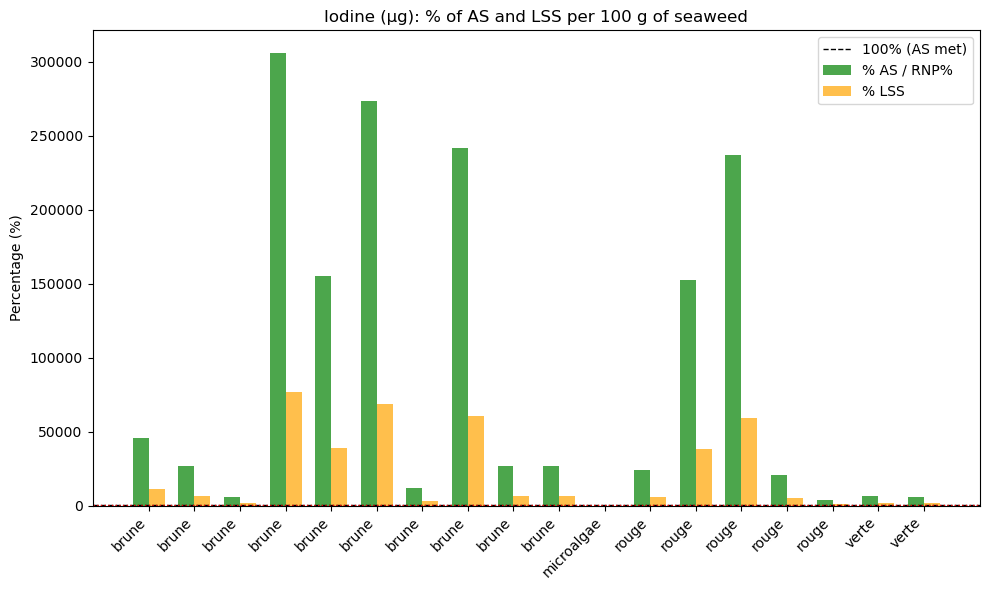

In [146]:
df = df_wide


import matplotlib.pyplot as plt

def plot_nutrient_bars(df, nutrient, as_col, lss_col):
    """
    Plots %AS and %LSS for a given nutrient across different seaweeds.
    
    Parameters:
    df      : dataframe with seaweed rows and nutrient % columns
    nutrient: str, nutrient name for title
    as_col  : str, column with %AS values
    lss_col : str, column with %LSS values
    """
    seaweeds = df["Type d'algue"]
    as_vals = df[as_col]
    lss_vals = df[lss_col]
    
    x = range(len(seaweeds))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10,6))
    
    # Bars
    ax.bar([i - width/2 for i in x], as_vals, width, label="% AS / RNP%", color="green", alpha=0.7)
    ax.bar([i + width/2 for i in x], lss_vals, width, label="% LSS", color="orange", alpha=0.7)
    
    # Reference lines
    ax.axhline(100, color="black", linestyle="--", linewidth=1, label="100% (AS met)")
    ax.axhline(100, color="red", linestyle=":", linewidth=1)  # risk threshold is shown by %LSS
    
    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(seaweeds, rotation=45, ha="right")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"{nutrient}: % of AS and LSS per 100 g of seaweed")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Example usage:
plot_nutrient_bars(df_wide, 
                   nutrient="Iodine (µg)", 
                   as_col="AS / RNP%_Iodine (µg/100g)", 
                   lss_col="LSS%_Iodine (µg/100g)")



In [147]:
print(df_wide.filter(like="Iodine").head())


   AS / RNP%_Iodine (µg/100g)  Amount_Iodine (µg/100g)  LSS%_Iodine (µg/100g)
0                45733.333333                  68600.0           11433.333333
1                26666.666667                  40000.0            6666.666667
2                 6000.000000                   9000.0            1500.000000
3               305866.666667                 458800.0           76466.666667
4               155200.000000                 232800.0           38800.000000


In [148]:
nutrient_key_map = {
    "Fibres (g/100g)": "Fibres_g",
    "Protein (g/100g)": "Protein_g",
    "Calcium (mg/100g)": "Calcium_mg",
    "Iron (mg/100g)": "Iron_mg",
    "Iodine (µg/100g)": "Iodine_µg"
}


# ---- STEP 1: Compute %AS and %LSS ----
# Create dicts for AS/LSS lookup
AS_dict = df_RI_women.set_index("Nutrient")["AS / RNP"].to_dict()
LSS_dict = df_RI_women.set_index("Nutrient")["LSS"].to_dict()

df_result = df_RI_perc_filtered.copy()

exclude_cols = ["alim_code", "Algue", "alim_ssgrp_nom_eng", "Type d'algue"]

# Loop over nutrients
for nutrient in [col for col in df_RI_perc_filtered.columns if col not in exclude_cols]:
    key = nutrient_key_map[nutrient]
    df_result[f"{nutrient}_AS%"] = df_RI_perc_filtered[nutrient] / AS_dict[key] * 100
    df_result[f"{nutrient}_LSS%"] = df_RI_perc_filtered[nutrient] / LSS_dict[key] * 100

# ---- Final table: per seaweed ----
from IPython.display import display
display("Seaweed nutrition vs AS/RNP or LSS", df_result)


'Seaweed nutrition vs AS/RNP or LSS'

,Type d'algue,Algue,Fibres (g/100g),Protein (g/100g),Calcium (mg/100g),Iron (mg/100g),Iodine (µg/100g),Fibres (g/100g)_AS%,Fibres (g/100g)_LSS%,Protein (g/100g)_AS%,Protein (g/100g)_LSS%,Calcium (mg/100g)_AS%,Calcium (mg/100g)_LSS%,Iron (mg/100g)_AS%,Iron (mg/100g)_LSS%,Iodine (µg/100g)_AS%,Iodine (µg/100g)_LSS%
101,brune,Wakamé atlantique (Alaria esculenta),42.9,12.20,771.0,44.60,362000.0,171.6,NaN,24.497992,NaN,81.157895,30.84,278.750,111.50,241333.333333,60333.333333
268,brune,Fucus vésiculeux (Fucus vesiculosus),46.7,6.40,1256.0,13.10,40500.0,186.8,NaN,12.851406,NaN,132.210526,50.24,81.875,32.75,27000.000000,6750.000000
479,rouge,Lichen de mer ou pioca ou goémon rouge (Chond...,35.5,16.70,911.0,18.10,31300.0,142.0,NaN,33.534137,NaN,95.894737,36.44,113.125,45.25,20866.666667,5216.666667
943,rouge,Dulse (Palmaria palmata),29.2,16.90,577.0,29.30,229000.0,116.8,NaN,33.935743,NaN,60.736842,23.08,183.125,73.25,152666.666667,38166.666667
1258,rouge,Gracilaire ou ogonori (Gracilaria verrucosa),25.4,17.80,770.0,36.00,355800.0,101.6,NaN,35.742972,NaN,81.052632,30.80,225.000,90.00,237200.000000,59300.000000
1431,brune,Kombu ou kombu japonais (Laminaria japonica),34.1,7.90,811.0,13.00,232800.0,136.4,NaN,15.863454,NaN,85.368421,32.44,81.250,32.50,155200.000000,38800.000000
1472,rouge,Nori (Porphyra sp.),36.8,30.20,440.0,36.40,5600.0,147.2,NaN,60.642570,NaN,46.315789,17.60,227.500,91.00,3733.333333,933.333333
1849,brune,Ascophylle noueux ou goémon noir (Ascophyllum...,43.6,7.40,1601.0,19.30,68600.0,174.4,NaN,14.859438,NaN,168.526316,64.04,120.625,48.25,45733.333333,11433.333333
2516,brune,Kombu royal (Saccharina latissima),30.2,9.90,838.0,24.10,410000.0,120.8,NaN,19.879518,NaN,88.210526,33.52,150.625,60.25,273333.333333,68333.333333
2517,verte,Ao-nori (Enteromorpha sp.),35.1,13.60,1554.0,205.00,9900.0,140.4,NaN,27.309237,NaN,163.578947,62.16,1281.250,512.50,6600.000000,1650.000000


### Need to complete with Fat and SatFat recommendations by reading more from source below

In [149]:
from numpy import nan
""

df_recommendations_women = pd.DataFrame({
    "Nutrient": ["Fibres_g", "Protein_g", "Calcium_mg", "Iodine_µg", "Fat_g", "FA saturated_g", "Iron_mg"],
    "AS / RNP": [30, 58, 950, 150, 'Fat', 'SatFat', 16],   # Apports satisfaisants
    "LSS": [nan, 245, 2500, 600, 'Fat', 'Fat_satured', 40]  # Limite supérieure de sécurité
})




df_recommendations_men = pd.DataFrame({
    "Nutrient": ["Fibres_g", "Protein_g", "Calcium_mg", "Iodine_µg", "Fat_g", "FA saturated_g", "Iron_mg"],
    "AS / RNP": [30, 58, 950, 150, 'Fat', 'SatFat', 11],   # Apports satisfaisants
    "LSS": [nan, 245, 2500, 600, 'Fat', 'Fat_satured', 40]  # Limite supérieure de sécurité
})
nutrients_list_step1 = [
    "Fibres (g/100g)",
    "Protein (g/100g)",
    "Calcium (mg/100g)",
    "Iodine (µg/100g)",
    "Fat (g/100g)",
    "FA saturated (g/100g)",
    "Iron (mg/100g)"
]

# AS = for Iodine, 
# RNP = for Calcium
# ANC protein = 58g is for a person weighing 70kg
# ANC protein: 0.83 g/kg poids corporel, according to: NUT-Ra-Proteines.pdf
# LSS protein = une limite à 20 % de l’AET, according to https://www.anses.fr/fr/system/files/NUT2012SA0103Ra-1.pdf, p. 16
# LSS protein = not official, but AFSSA was leading to wards making it 3.5 g / kg / day, so 245g for a 70 kg person
# protein numbers = AFSSA 2007, according to this article: https://efsa.onlinelibrary.wiley.com/doi/epdf/10.2903/j.efsa.2012.2557




In [150]:
df_recommendations_women

,Nutrient,AS / RNP,LSS
0,Fibres_g,30,NaN
1,Protein_g,58,245
2,Calcium_mg,950,2500
3,Iodine_µg,150,600
4,Fat_g,Fat,Fat
5,FA saturated_g,SatFat,Fat_satured
6,Iron_mg,16,40


# Total fat
Source on Fat to look into more: https://www.nutritiondusport.fr/wp-content/uploads/2013/09/efsa-journal-2010-1461-acid-gras.pdf

"Fat is an important dense source of energy and facilitates the absorption of fat-soluble dietary
components such as vitamins. Fats and oils are also important sources of essential fatty acids (EFA).
High-fat diets may decrease insulin-sensitivity and are positively associated with changes in fasting
and postprandial factor VII, which may increase cardiovascular risk. However, a precise dose-
response relationship can not be defined. There is evidence that a moderate fat intake (<35 E%) is
accompanied by a reduced energy intake and therefore moderate weight reduction and/or prevention
of weight gain. However, there are not sufficient data to define a Lower Threshold Intake (LTI) or
Tolerable Upper Intake Level (UL) for total fat. The Panel concludes that only a Reference Intake
range can be established for total fat intake, partly based on practical considerations (e.g. current
levels of intake, achievable dietary patterns). At the lowest observed intake of total fat (20 E%) in
European countries no overt signs of deficiencies have been observed nor adverse effects on blood
lipids. Total fat intakes > 35 E% may be compatible with both good health and normal body weight
depending on dietary patterns and the level of physical activity. The Panel proposes to set for adults a
lower bound of the Reference Intake range of 20 E% and an upper bound of 35 E%.
Fat intake in infants, which is high during the breastfeeding period, can gradually be reduced in the
second half of the first year of life from the start of the complementary feeding period up to three
years of age: 40 E% in the 6 to 12 month period and 35 to 40 E% in the 2nd and 3rd year of life. Fat
intakes below 25 E% have been associated with low vitamin levels in some young children."

## Reference table for establishing percentages

In [151]:
# source pour les minéraux : https://www.anses.fr/fr/content/les-references-nutritionnelles-en-vitamines-et-mineraux, https://anses.hal.science/anses-03431491v1/document
# sources pour les protéines : https://www.anses.fr/system/files/NUT-Ra-Proteines.pdf, https://www.anses.fr/en/system/files/NUT2012SA0103Ra-1EN.pdf
# source for weight references for calculating RNP for protein : https://www.anses.fr/fr/system/files/NUT2012SA0103Ra-2.pdf --> Annexe2, https://efsa.onlinelibrary.wiley.com/doi/pdf/10.2903/j.efsa.2013.3005

reference_values = {
    'Iron (mg/100g)': {
        'AS - Nourrissons < 6 mois': 0.3,
        'RNP - Nourrissons > 6 mois': 11,
        'RNP - Enfants 1-3 ans': 4.5,
        'RNP - Enfants 4-10 ans': 8,
        'RNP - Adolescents 11-17 ans': 11,
        'RNP - Adultes 18-24 ans': 11,
        'RNP - Adultes 25 ans et plus': 11,
        'RNP - Femmes enceintes ou allaitantes': 16,
        'LSS': 25  # Same across subgroups
    },
    'Iodine (µg/100g)': {
        'AS - Nourrissons < 6 mois': 90,
        'AS - Nourrissons > 6 mois': 70,
        'AS - Enfants 1-3 ans': 90,
        'AS - Enfants 4-6 ans': 90,
        'AS - Enfants 7-10 ans': 90,
        'AS - Adolescents 11-14 ans': 120,
        'AS - Adolescents 15-17 ans': 130,
        'AS - Hommes et femmes de 18 et plus': 150,
        'AS - Femmes enceintes ou allaitantes': 200,
        'LLS - Enfants 1-3 ans': 200,
        'LLS - Enfants 4-6 ans': 250,
        'LLS - Enfants 7-10 ans': 300,
        'LLS - Adolescents 11-14 ans': 450,
        'LLS - Adolescents 15-17 ans': 500,
        'LLS - Hommes et femmes de 18 et plus': 600,
        'LLS - Femmes enceintes ou allaitantes': 600,
    },
    'Calcium (mg/100g)': {
        'AS - Nourrissons < 6 mois': 200,
        'AS - Nourrissons > 6 mois': 280,
        'RNP - Enfants 1-3 ans': 450,
        'RNP - Enfants 4-10 ans': 800,
        'RNP - Adolescents 11-17 ans': 1150,
        'RNP - Adultes 18-24 ans': 1000,
        'RNP - Adultes 25 ans et plus': 950,
        'RNP - Femmes enceintes ou allaitantes': 950,
        'LSS': 2500  # Same 18 ans et +  subgroups
    },
    'Protein (g/100g)': {
        'RNP - Nourrissons < 6 mois': 10.62,
        'RNP - Nourrissons > 6 mois': 11.79,
        'RNP - Enfants 1-3 ans': 12.6,
        'RNP - Enfants 4-6 ans': 19.8,
        'RNP - Enfants 7-10 ans': 27.16,
        'RNP - Adolescents 11-14 ans': 37.2,
        'RNP - Adolescents 15-17 ans': 51.15,
        'RNP - Adultes hommes': 58.1,
        'RNP - Adultes femmes': 49.8,
        'RNP - Femmes enceintes': 56.8,
        'RNP - Femmes allaitantes': 66.8,
        'LSS': None  
        },
    'Fat (µg/100g)': {
        'AS - Nourrissons < 6 mois': 200,
        'AS - Nourrissons > 6 mois': 280,
        'RNP - Enfants 1-3 ans': 450,
        'RNP - Enfants 4-10 ans': 800,
        'RNP - Adolescents 11-17 ans': 1150,
        'RNP - Adultes 18-24 ans': 1000,
        'RNP - Adultes 25 ans et plus': 950,
        'RNP - Femmes enceintes ou allaitantes': 950,
        'LSS': 2500  # Same 18 ans et +  subgroups
        },
}


reference_values_protein = {
    "Protein (g/day)": {
        # Infants
        "AS - Nourrissons < 6 mois": {
            "value": 1.77 * 6,   # = 10.62 g/day
            "note": "Calculé avec un poids de référence de 6 kg"
        },
        "AS - Nourrissons 6-12 mois": {
            "value": 1.31 * 9,   # = 11.79 g/day
            "note": "Calculé avec un poids de référence de 9 kg"
        },

        # Children
        "RNP - Enfants 1-2 ans": {
            "value": 1.05 * 12,  # = 12.6 g/day
            "note": "Calculé avec un poids de référence de 12 kg"
        },
        "RNP - Enfants 4-6 ans": {
            "value": 0.99 * 20,  # = 19.8 g/day
            "note": "Calculé avec un poids de référence de 20 kg"
        },
        "RNP - Enfants 7-10 ans": {
            "value": 0.97 * 28,  # = 27.16 g/day
            "note": "Calculé avec un poids de référence de 28 kg"
        },

        # Adolescents
        "RNP - Adolescents 11-14 ans": {
            "value": 0.93 * 40,  # = 37.2 g/day
            "note": "Calculé avec un poids de référence de 40 kg"
        },
        "RNP - Adolescents 15-17 ans": {
            "value": 0.93 * 55,  # = 51.15 g/day
            "note": "Calculé avec un poids de référence de 55 kg"
        },

        # Adults
        "RNP - Adultes hommes": {
            "value": 0.83 * 70,  # = 58.1 g/day
            "note": "Calculé avec un poids de référence de 70 kg"
        },
        "RNP - Adultes femmes": {
            "value": 0.83 * 60,  # = 49.8 g/day
            "note": "Calculé avec un poids de référence de 60 kg"
        },

        # Pregnancy & lactation
        "RNP - Femmes enceintes": {
            "value": (0.83 * 60) + 7,  # = 56.8 g/day
            "note": "Poids de référence 60 kg + 7 g/j supplémentaires (ANSES)"
        },
        "RNP - Femmes allaitantes": {
            "value": (0.83 * 60) + 17,  # = 66.8 g/day
            "note": "Poids de référence 60 kg + 17 g/j supplémentaires (ANSES)"
        },

        # No LSS for protein
        "LSS": {
            "value": None,
            "note": "ANSES ne définit pas de LSS pour les protéines"
        }
    }
}
